End to End Implementation of ZFNet Arch from dataset to model Arch to Training to Evaluation
(Some Modification wrt usae of data and training method is nessosory to train this model on Single Core GPU in Laptop, Arch Remains same.)

A Note : We did Run this model as this is bit more expensive than alexnet due to small filter size. We use the 90 epochs alexnet we trained for section 4 experiment reproduction

### Set Up

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import keras
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn.functional as F
import torchvision.transforms.functional as TF

In [3]:
torch.cuda.is_available()

True

In [4]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
keras.mixed_precision.set_global_policy("mixed_float16")
keras.config.set_image_data_format("channels_first")
print(keras.config.image_data_format())

channels_first


In [5]:
model_name = "model/zfnet.keras"

### The Dataset (3)

> Info : ImageNet dataset of over 15 million labeled high- resolution images belonging to roughly 22,000 categories.

> Paper : The model was trained on the ImageNet 2012 train ing set (1.3 million images, spread over 1000 different classes).

> Me : We use 1261406 (~1.26 M) labeled high-resolution imaged of ImageNet 2010 (Not 2012) train dataset
       same 2010 validation set for validating and evaluating the model.


In [6]:
batch_size = 128

In [7]:
dir = "../../Datasets/ILSVRC2010_images"
print(f"Validation images: {len(os.listdir(os.path.join(dir, 'val')))}")

Validation images: 50000


In [8]:
from scipy.io import loadmat
meta = loadmat(os.path.join(dir, "meta.mat"))
synsets = meta["synsets"]
print(meta.keys())
print(synsets)

dict_keys(['__header__', '__version__', '__globals__', 'cost_matrix', 'synsets'])
[[(array([[1]], dtype=uint8), array(['n07711080'], dtype='<U9'), array(['french fries, french-fried potatoes, fries, chips'], dtype='<U49'), array(['strips of potato fried in deep fat'], dtype='<U34'), array([[0]], dtype=uint8), array([], shape=(1, 0), dtype=uint8), array([[0]], dtype=uint8), array([[1487]], dtype=uint16))]
 [(array([[2]], dtype=uint8), array(['n07711569'], dtype='<U9'), array(['mashed potato'], dtype='<U13'), array(['potato that has been peeled and boiled and then mashed'],
        dtype='<U54'), array([[0]], dtype=uint8), array([], shape=(1, 0), dtype=uint8), array([[0]], dtype=uint8), array([[1245]], dtype=uint16))                         ]
 [(array([[3]], dtype=uint8), array(['n07767549'], dtype='<U9'), array(['black olive, ripe olive'], dtype='<U23'), array(['olives picked ripe and cured in brine then dried or pickled or preserved canned or in oil'],
        dtype='<U89'), array([[0]

In [9]:
print(meta["synsets"].shape)
print(meta["synsets"][0,0])

(1676, 1)
(array([[1]], dtype=uint8), array(['n07711080'], dtype='<U9'), array(['french fries, french-fried potatoes, fries, chips'], dtype='<U49'), array(['strips of potato fried in deep fat'], dtype='<U34'), array([[0]], dtype=uint8), array([], shape=(1, 0), dtype=uint8), array([[0]], dtype=uint8), array([[1487]], dtype=uint16))


In [10]:
rows = []
for s in synsets:
    s = s[0]
    ilsvrc_id = int(s[0][0][0])
    wnid = s[1][0]
    words = s[2][0]
    num_children = int(s[4][0][0])
    rows.append([ilsvrc_id, wnid, words, num_children])

df = pd.DataFrame(rows, columns=["idx", "wnid", "class_name", "children"])
print(len(df))
df

1676


,idx,wnid,class_name,children
0,1,n07711080,"french fries, french-fried potatoes, fries, chips",0
1,2,n07711569,mashed potato,0
2,3,n07767549,"black olive, ripe olive",0
3,4,n03314780,face powder,0
4,5,n07739344,"crab apple, crabapple",0
...,...,...,...,...
1671,1672,n08061042,"business, concern, business concern, business ...",1
1672,1673,n08057633,"carrier, common carrier",1
1673,1674,n03671473,line,1
1674,1675,n04048568,"railway, railroad, railroad line, railway line...",1


In [11]:
imagenet1000 = (df[df["children"] == 0].sort_values("idx").reset_index(drop=True))
print(len(imagenet1000))
imagenet1000

1000


,idx,wnid,class_name,children
0,1,n07711080,"french fries, french-fried potatoes, fries, chips",0
1,2,n07711569,mashed potato,0
2,3,n07767549,"black olive, ripe olive",0
3,4,n03314780,face powder,0
4,5,n07739344,"crab apple, crabapple",0
...,...,...,...,...
995,996,n04542943,waffle iron,0
996,997,n04517823,"vacuum, vacuum cleaner",0
997,998,n03207941,"dishwasher, dish washer, dishwashing machine",0
998,999,n04070727,"refrigerator, icebox",0


In [12]:
mapping = dict(zip(imagenet1000["idx"], imagenet1000["wnid"]))
mapping

{1: 'n07711080',
 2: 'n07711569',
 3: 'n07767549',
 4: 'n03314780',
 5: 'n07739344',
 6: 'n07742313',
 7: 'n07745940',
 8: 'n07743544',
 9: 'n07743902',
 10: 'n07744246',
 11: 'n07744811',
 12: 'n07745466',
 13: 'n07746186',
 14: 'n07767171',
 15: 'n07747607',
 16: 'n07749446',
 17: 'n07749582',
 18: 'n07749969',
 19: 'n07751451',
 20: 'n07753113',
 21: 'n07753275',
 22: 'n07753592',
 23: 'n07754684',
 24: 'n07757132',
 25: 'n07758680',
 26: 'n07760859',
 27: 'n07762913',
 28: 'n07764155',
 29: 'n07765208',
 30: 'n07765361',
 31: 'n07766173',
 32: 'n07768694',
 33: 'n07769584',
 34: 'n07727048',
 35: 'n07729485',
 36: 'n07725531',
 37: 'n07726095',
 38: 'n07720277',
 39: 'n07723559',
 40: 'n07732747',
 41: 'n07736692',
 42: 'n07720875',
 43: 'n07721195',
 44: 'n07721678',
 45: 'n07734292',
 46: 'n07735404',
 47: 'n07735803',
 48: 'n07713763',
 49: 'n07714448',
 50: 'n07714571',
 51: 'n07714990',
 52: 'n07715103',
 53: 'n07715221',
 54: 'n07716358',
 55: 'n07716906',
 56: 'n07717410',
 

> Paper : Each RGB image was preprocessed by resizing the smallest dimension to 256, cropping the center 256x256 region, subtracting the per-pixel mean (across all images) and then using 10 different sub-crops of size 224x224 (corners + center with(out) horizontal flips), (Its same as Alexnet)

> Me : Down-sampled the images to a fixed resolution of 256 × 256. Given a rectangular image, we first rescaled the image such that the shorter side was of length 256, and then cropped out the central 256 × 256 patch from the resulting image. Then subtracting the mean activity over the training set from each pixel. Implemented this data preprocessing as utils (Its Same as Alexnet)
  We do this by extracting random 224 × 224 patches (and their horizontal reflections) from the 256 × 256 images
and training our network on these extracted patches. (Same as in ZFNET Paper)

In [13]:
# preprocess utils
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [14]:
label_path = os.path.join(dir, "ILSVRC2010_validation_ground_truth.txt")
val_df = pd.read_csv(label_path, header=None)
val_df.columns = pd.Index(["class"])
val_df['idx'] = val_df["class"]
val_df["id"] = val_df.index+1
val_df["id"] = val_df["id"].astype(str).str.zfill(5)
val_df['class'] = val_df["class"].astype(int).map(mapping)
val_df

,class,idx,id
0,n09428293,78,00001
1,n02871525,854,00002
2,n02119789,435,00003
3,n04141975,541,00004
4,n03000247,973,00005
...,...,...,...
49995,n01728572,467,49996
49996,n03351979,646,49997
49997,n09246464,68,49998
49998,n13136316,93,49999


In [15]:
prefix = "ILSVRC2010_val_000"
val_df['id'] = prefix+val_df['id'].astype(str) + '.JPEG'

In [16]:
train_dataset = ImageFolder(os.path.join(dir, "train"), transform=preprocess)
train_data = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
idx_to_class = {i:j for j, i in train_dataset.class_to_idx.items()}

In [17]:
images, labels = next(iter(train_data))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([128, 3, 224, 224])
Labels batch shape: torch.Size([128])


In [18]:
labels[0]

tensor(424)

In [19]:
np.argmax(labels[0])

tensor(0)

In [20]:
images[0]

tensor([[[0.7608, 0.7490, 0.7608,  ..., 0.7529, 0.7451, 0.7294],
         [0.7529, 0.7451, 0.7451,  ..., 0.7333, 0.7490, 0.7216],
         [0.7529, 0.7451, 0.7490,  ..., 0.7569, 0.7490, 0.7333],
         ...,
         [0.2745, 0.2235, 0.1922,  ..., 0.0902, 0.0902, 0.0745],
         [0.3176, 0.2824, 0.2314,  ..., 0.0784, 0.0824, 0.0745],
         [0.2706, 0.2706, 0.2706,  ..., 0.0196, 0.0235, 0.0275]],

        [[0.8980, 0.9020, 0.8980,  ..., 0.8196, 0.7843, 0.8078],
         [0.8980, 0.9098, 0.9020,  ..., 0.8118, 0.8000, 0.8039],
         [0.8863, 0.8941, 0.9137,  ..., 0.8392, 0.8157, 0.8078],
         ...,
         [0.2471, 0.2039, 0.2039,  ..., 0.0902, 0.0863, 0.0706],
         [0.2392, 0.2235, 0.2118,  ..., 0.0706, 0.0745, 0.0667],
         [0.2235, 0.2353, 0.2510,  ..., 0.0235, 0.0275, 0.0275]],

        [[0.7961, 0.8118, 0.8157,  ..., 0.7529, 0.7373, 0.7765],
         [0.8078, 0.8196, 0.8275,  ..., 0.7569, 0.7765, 0.7765],
         [0.8078, 0.8157, 0.8471,  ..., 0.7882, 0.7922, 0.

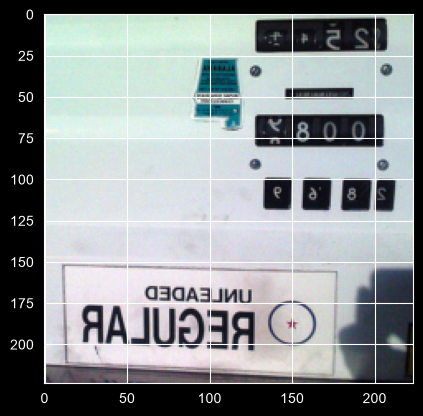

In [21]:
plt.imshow(np.transpose(images[0], (1, 2, 0)))
plt.show()

In [22]:
class ImageNetValDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, class_to_idx=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        wnid_label = self.dataframe.iloc[idx]['class']
        label = self.class_to_idx[wnid_label]
        if self.transform:
            image = self.transform(image)
        return image, label

val_dataset = ImageNetValDataset(
    dataframe=val_df,
    img_dir=os.path.join(dir, "val"),
    transform=preprocess,
    class_to_idx=train_dataset.class_to_idx)


val_data = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [23]:
def get_class_name(target_id):
    return imagenet1000.loc[imagenet1000['wnid'] == target_id, 'class_name'].values[0].split(",")[0]

val_batch_imgs, val_batch_labels = next(iter(val_data))
val_imgs_np = val_batch_imgs.numpy() if hasattr(val_batch_imgs, 'numpy') else val_batch_imgs

In [24]:
images, labels = next(iter(val_data))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([128, 3, 224, 224])
Labels batch shape: torch.Size([128])


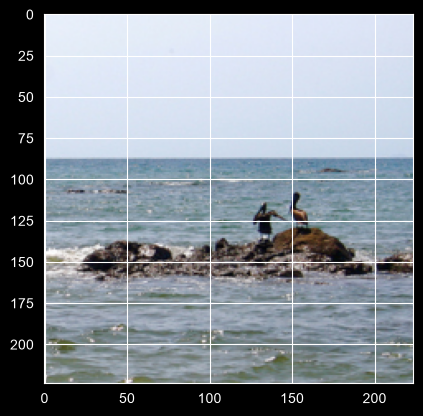

n09428293 seashore


In [25]:
plt.imshow(np.transpose(images[0], (1, 2, 0)))
plt.show()
class_id = idx_to_class[int(labels[0])]
print(class_id, get_class_name(class_id))

### Model Architecture (3)

In [26]:
# Local response normalization
@keras.saving.register_keras_serializable()
class LocalResponseNormalization(keras.layers.Layer):
    def call(self, x):
        return torch.nn.functional.local_response_norm(x, size=5, alpha=1e-4, beta=0.75, k=2.0, )

In [27]:
"""
3. Visualization of the first layer filters during training reveals that a few of them dominate
To combat this, we renormalize each filter in the convolutional layers whose RMS value exceeds a fixed radius of 0.1 to this fixed radius.
This is crucial, especially in the first layer of the model, where the input images are roughly in the [-128,128] range.
"""
@keras.saving.register_keras_serializable()
class RMSConstraint(keras.constraints.Constraint):
    def __init__(self, radius=0.1):
        self.radius = radius

    def __call__(self, w):
        rms = tf.sqrt(tf.reduce_mean(tf.square(w), axis=[0, 1, 2], keepdims=True))
        exceeds_radius = rms > self.radius
        scale_factor = self.radius / (rms + keras.backend.epsilon())
        w_clipped = w * tf.where(exceeds_radius, scale_factor, tf.ones_like(scale_factor))
        return w_clipped

    def get_config(self):
        return {'radius': self.radius}



In [28]:
inputs = keras.Input(shape=(3, 224, 224))

x = keras.layers.ZeroPadding2D(1)(inputs)

# Layer1
x = keras.layers.Conv2D(filters=96, kernel_size=7, strides=2, padding="valid", activation="relu", name="conv1",
                        kernel_regularizer=keras.regularizers.l2(5e-4), kernel_constraint=RMSConstraint(0.1))(x) # Weight Decay using l2 From (6). ReLU from (5.1
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool1", padding="same")(x)
x = LocalResponseNormalization(name="lrn1")(x)

# Layer2
x = keras.layers.Conv2D(filters=256, kernel_size=5, strides=2, padding="valid", activation="relu", name="conv2",
                        kernel_regularizer=keras.regularizers.l2(5e-4), kernel_constraint=RMSConstraint(0.1))(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool2", padding="same")(x)
x = LocalResponseNormalization(name="lrn2")(x)

# Layer3
x = keras.layers.Conv2D(filters=384, kernel_size=3, strides=1, padding="same", activation="relu", name="conv3",
                        kernel_regularizer=keras.regularizers.l2(5e-4), kernel_constraint=RMSConstraint(0.1))(x)

# Layer4
x = keras.layers.Conv2D(filters=384, kernel_size=3, strides=1, padding="same", activation="relu", name="conv4",
                        kernel_regularizer=keras.regularizers.l2(5e-4), kernel_constraint=RMSConstraint(0.1))(x)

# Layer5
x = keras.layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu", name="conv5",
                        kernel_regularizer=keras.regularizers.l2(5e-4), kernel_constraint=RMSConstraint(0.1))(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool5")(x)

# Layer 6
x = keras.layers.Flatten(name="flatten")(x)
x = keras.layers.Dense(4096, activation="relu", name="dense1", kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.Dropout(0.5)(x) # From 5.2

# Layer 7
x = keras.layers.Dense(4096, activation="relu", name="dense2", kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.Dropout(0.5)(x) # From 5.2

# Layer 8
outputs = keras.layers.Dense(1000, activation="softmax", name="dense3", kernel_regularizer=keras.regularizers.l2(5e-4))(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 3, 226, 226)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 110, 110)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 96, 55, 55)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn1                            │ (None, 96, 55, 55)     │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 256, 26, 26)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 13, 13)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn2                            │ (None, 256, 13, 13)    │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 384, 13, 13)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 384, 13, 13)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 256, 13, 13)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 256, 6, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,357,608 (237.88 MB)

 Trainable params: 62,357,608 (237.88 MB)

 Non-trainable params: 0 (0.00 B)

Model Arch Diagram from Paper :

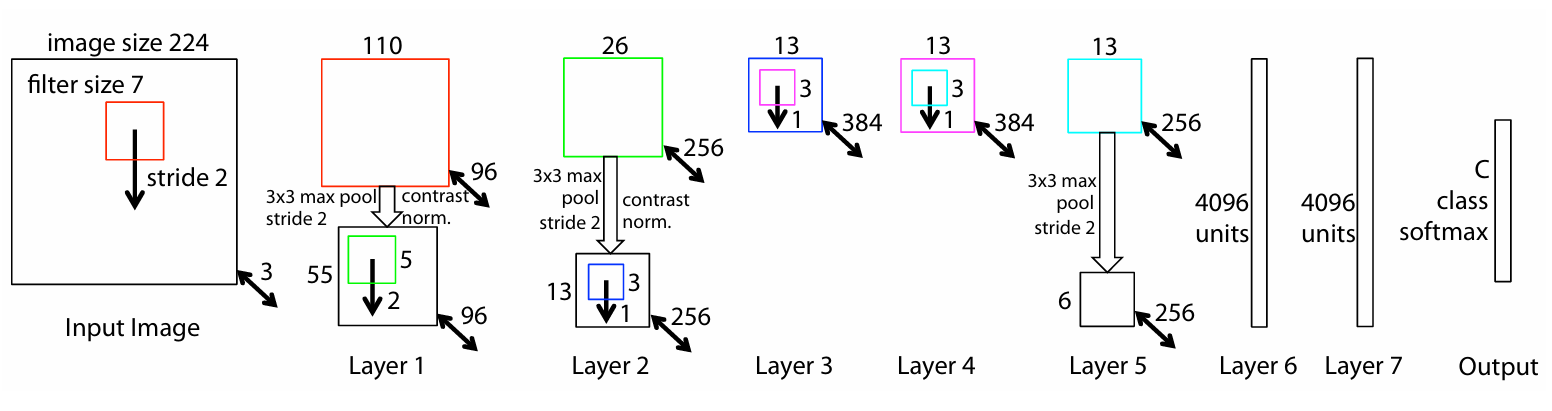

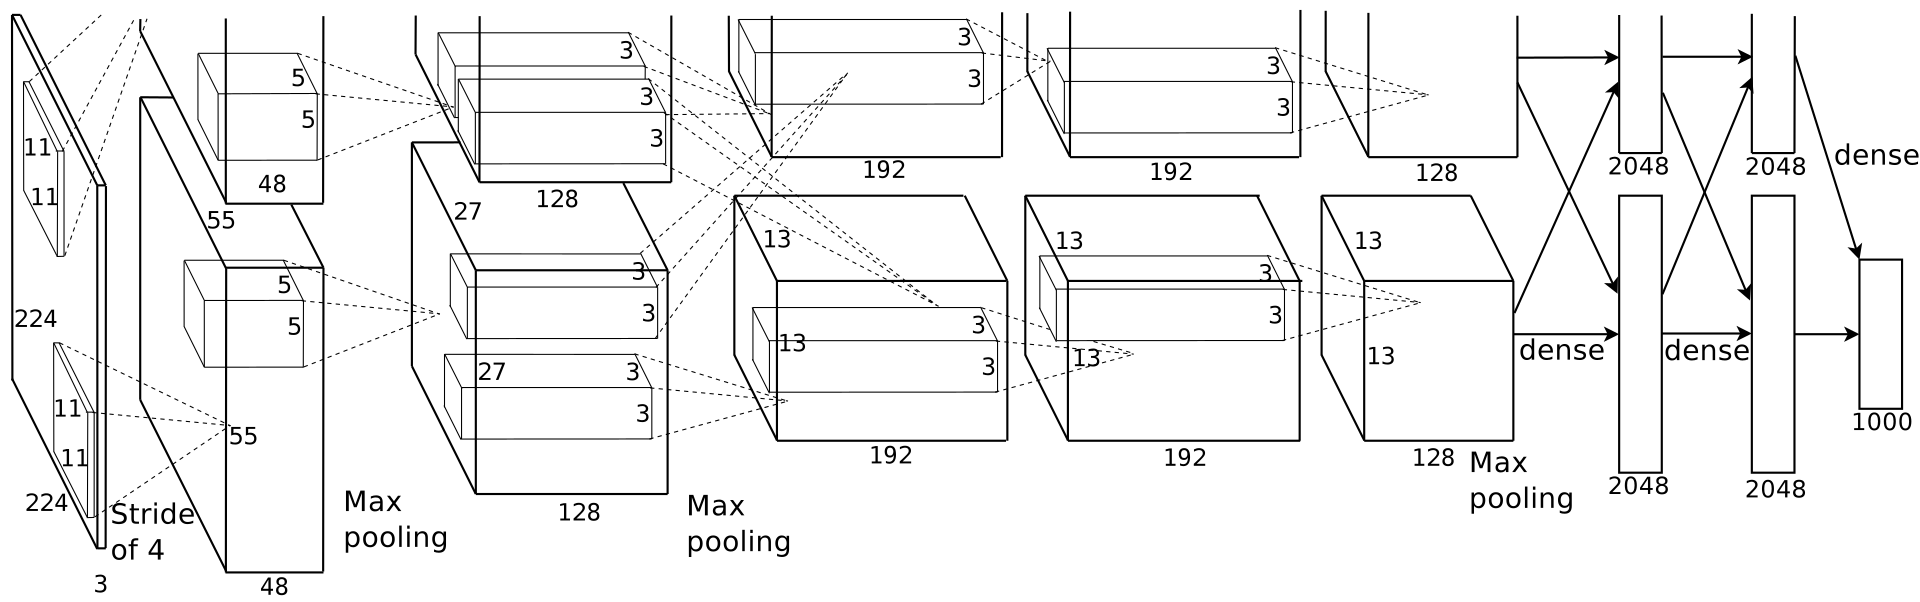

### Training/Learning (3)

> Paper :
Stochastic gradient descent with a mini-batch size of 128 was used to update the parameters, starting with a learning rate of 10^−2, in conjunction with a momentum term of 0.9.
We anneal the learning rate throughout training manually when the validation error plateaus.
Dropout (Hinton et al., 2012) is used in the fully con nected layers (6 and 7) with a rate of 0.5.
All weights are initialized to 10^−2 and biases are set to 0.


> Me :
We trained our models using AdamW with a batch size of 192, for faster Training
We leave all Weight Initialization to keras library default

In [29]:
# Optimizer
# optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9) # Paper usage

# We will use AdamW
optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=5e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-8)


In [30]:
torch.backends.cudnn.benchmark = True
if os.path.exists(model_name): # Mechanism to continue training model from where it stopped
    model = keras.models.load_model(model_name)
else:
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=[
    keras.metrics.SparseCategoricalAccuracy(name="accuracy"), keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")])

In [31]:
# LR Scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1)

In [32]:
checkpoint = keras.callbacks.ModelCheckpoint(model_name, monitor="val_accuracy", save_best_only=True)

In [ ]:
# Training : Paper used 70 Epochs and it took 12 days on a single GTX580 GPU.
#            Use Trained 70 Epochs and it took 48 Hrs on Single RTX 5050 GPU.

history = model.fit(train_data, validation_data=val_data, epochs=1, callbacks=[reduce_lr, checkpoint])
df = pd.DataFrame(history.history)
df.to_csv(model_name.split(".")[0]+".csv")

C:\Users\PRASHANTH N\PycharmProjects\PaperClip\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a torch DataLoader. The DataLoader is expected to already be shuffled.
  self.data_adapter = data_adapters.get_data_adapter(


 389/9855 ━━━━━━━━━━━━━━━━━━━━ 35:11 223ms/step - accuracy: 0.0020 - loss: 7.3158 - top5: 0.0085

### Evaluation Plots

In [ ]:
history = pd.read_csv(model_name.split(".")[0]+".csv")

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["top5"], label="Train")
plt.plot(history["val_top5"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Top-5 Accuracy")
plt.title("Top-5 Accuracy")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["accuracy"], label="Train")
plt.plot(history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.show()

### Inference & Evaluation

In [ ]:
@keras.saving.register_keras_serializable()
class LocalResponseNormalization(keras.layers.Layer):
    def call(self, x):
        return torch.nn.functional.local_response_norm(x, size=5, alpha=1e-4, beta=0.75, k=2.0, )

@keras.saving.register_keras_serializable()
class RMSConstraint(keras.constraints.Constraint):
    def __init__(self, radius=0.1):
        self.radius = radius

    def __call__(self, w):
        rms = tf.sqrt(tf.reduce_mean(tf.square(w), axis=[0, 1, 2], keepdims=True))
        exceeds_radius = rms > self.radius
        scale_factor = self.radius / (rms + keras.backend.epsilon())
        w_clipped = w * tf.where(exceeds_radius, scale_factor, tf.ones_like(scale_factor))
        return w_clipped

    def get_config(self):
        return {'radius': self.radius}



model = keras.models.load_model(model_name)
model.summary()

In [ ]:
results = model.evaluate(val_data)

print(f"Loss          : {results[0]:.4f}")
print(f"Top-1 Accuracy: {results[1]:.4f}")
print(f"Top-5 Accuracy: {results[2]:.4f}")

In [ ]:
predictions = model.predict(val_data)

In [ ]:
predicted_classes = np.argmax(predictions, axis=1)
dataset = val_data.dataset
true_classes = [dataset.class_to_idx[label] for label in dataset.dataframe['class']]

In [ ]:
print(classification_report(true_classes, predicted_classes))

### AlexNet Model Load

In [26]:
@keras.saving.register_keras_serializable()
class LocalResponseNormalization(keras.layers.Layer):
    def call(self, x):
        return torch.nn.functional.local_response_norm(x, size=5, alpha=1e-4, beta=0.75, k=2.0, )

alexnet = "model/alexnet_copy.keras"
model = keras.models.load_model(alexnet)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 3, 228, 228)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 55, 55)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn1                            │ (None, 96, 55, 55)     │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 96, 27, 27)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 256, 27, 27)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn2                            │ (None, 256, 27, 27)    │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 13, 13)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 384, 13, 13)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 384, 13, 13)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 256, 13, 13)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 256, 6, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,756,694 (475.91 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,378,350 (237.95 MB)

### Filter Visualization (4)

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [28]:
def get_torch_conv_params(layer_name):
    layer = model.get_layer(layer_name)
    w_keras = layer.get_weights()[0] # (H, W, In, Out)
    w_torch = torch.tensor(w_keras).permute(3, 2, 0, 1).to(device)
    stride = layer.strides
    padding = 0 if layer.padding == 'valid' else w_keras.shape[0] // 2
    return w_torch, stride, padding

In [29]:
w1, s1, p1 = get_torch_conv_params('conv1')
w2, s2, p2 = get_torch_conv_params('conv2')
w3, s3, p3 = get_torch_conv_params('conv3')
w4, s4, p4 = get_torch_conv_params('conv4')
w5, s5, p5 = get_torch_conv_params('conv5')
pool_k, pool_s = 3, 2

In [30]:
def visualize_layer_torch(input_images, target_layer, feature_map_idx):
    try:
        if isinstance(input_images, torch.Tensor):
            img_tensor = input_images.clone().detach().to(device, dtype=torch.float32)
            input_np = input_images.cpu().numpy()
        else:
            img_tensor = torch.tensor(input_images, dtype=torch.float32).to(device)
            input_np = input_images
        x = img_tensor
        shapes, switches = {}, {}
        x = F.conv2d(x, w1, stride=s1, padding=p1)
        x = F.relu(x)
        shapes['c1'] = x.shape
        x, switches['p1'] = F.max_pool2d(x, kernel_size=pool_k, stride=pool_s, return_indices=True)
        if target_layer >= 2:
            x = F.conv2d(x, w2, stride=s2, padding=p2)
            x = F.relu(x)
            shapes['c2'] = x.shape
            x, switches['p2'] = F.max_pool2d(x, kernel_size=pool_k, stride=pool_s, return_indices=True)
        if target_layer >= 3:
            x = F.conv2d(x, w3, stride=s3, padding=p3)
            x = F.relu(x)
            shapes['c3'] = x.shape
        if target_layer >= 4:
            x = F.conv2d(x, w4, stride=s4, padding=p4)
            x = F.relu(x)
            shapes['c4'] = x.shape
        if target_layer >= 5:
            x = F.conv2d(x, w5, stride=s5, padding=p5)
            x = F.relu(x)
            shapes['c5'] = x.shape
            x, switches['p5'] = F.max_pool2d(x, kernel_size=pool_k, stride=pool_s, return_indices=True)
        max_vals_per_batch = x[:, feature_map_idx, :, :].amax(dim=(1, 2))
        batch_idx = torch.argmax(max_vals_per_batch).item()
        y = torch.zeros_like(x)
        flat_idx = torch.argmax(x[batch_idx, feature_map_idx, :, :])
        max_h, max_w = divmod(flat_idx.item(), x.shape[3])
        y[batch_idx, feature_map_idx, max_h, max_w] = x[batch_idx, feature_map_idx, max_h, max_w]
        if target_layer >= 5:
            y = F.max_unpool2d(y, switches['p5'], kernel_size=pool_k, stride=pool_s, output_size=shapes['c5'])
            y = F.relu(y)
            y = F.conv_transpose2d(y, w5, stride=s5, padding=p5)
        if target_layer >= 4:
            y = F.relu(y)
            y = F.conv_transpose2d(y, w4, stride=s4, padding=p4)
        if target_layer >= 3:
            y = F.relu(y)
            y = F.conv_transpose2d(y, w3, stride=s3, padding=p3)
        if target_layer >= 2:
            y = F.max_unpool2d(y, switches['p2'], kernel_size=pool_k, stride=pool_s, output_size=shapes['c2'])
            y = F.relu(y)
            y = F.conv_transpose2d(y, w2, stride=s2, padding=p2)
        y = F.max_unpool2d(y, switches['p1'], kernel_size=pool_k, stride=pool_s, output_size=shapes['c1'])
        y = F.relu(y)
        y = F.conv_transpose2d(y, w1, stride=s1, padding=p1)
        reconstruction = y[batch_idx].cpu().detach().numpy().transpose(1, 2, 0)
        original_img = input_np[batch_idx].transpose(1, 2, 0)
        r_min, r_max = reconstruction.min(), reconstruction.max()
        reconstruction = (reconstruction - r_min) / (r_max - r_min + 1e-5)
        return reconstruction, original_img
    except Exception as e:
        print(f"Caught error safely without killing kernel: {e}")
        return None, None

In [31]:
def feature_plot(n, layer, val_set):
    fig, axes = plt.subplots(n, n*2, figsize=(10, 5))
    plt.suptitle(f"Layer {layer} Feature Projections", fontsize=16, y=0.95)
    for i in range(n**2):
        val_images, val_labels = next(val_set)
        reconstructed_img, original_img = visualize_layer_torch(val_images, target_layer=layer, feature_map_idx=15)
        while sum(sum(sum(reconstructed_img))) == 0:
            val_images, val_labels = next(val_set)
            reconstructed_img, original_img = visualize_layer_torch(val_images, target_layer=layer, feature_map_idx=15)
        if reconstructed_img is not None:
            row, col = divmod(i, n)
            axes[row, col].imshow(reconstructed_img, interpolation='lanczos', vmin=0.45, vmax=0.55)
            axes[row, col].axis('off')
            axes[row, col + n].imshow(original_img)
            axes[row, col + n].axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()

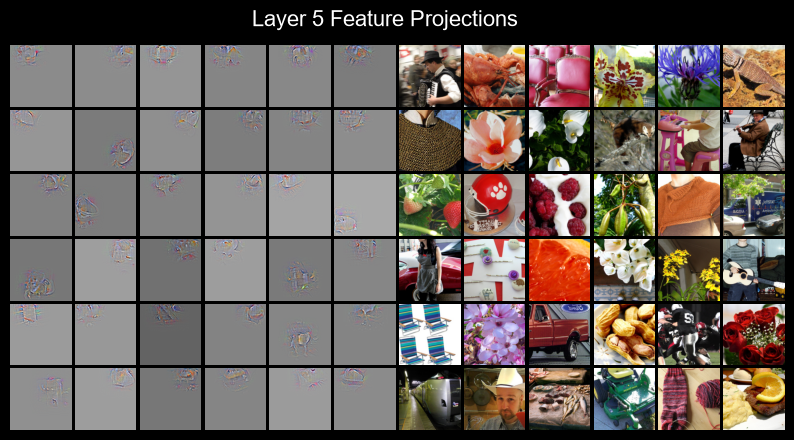

In [32]:
n = 6
layer = 5
val_set = iter(val_data)
feature_plot(n, layer, val_set)

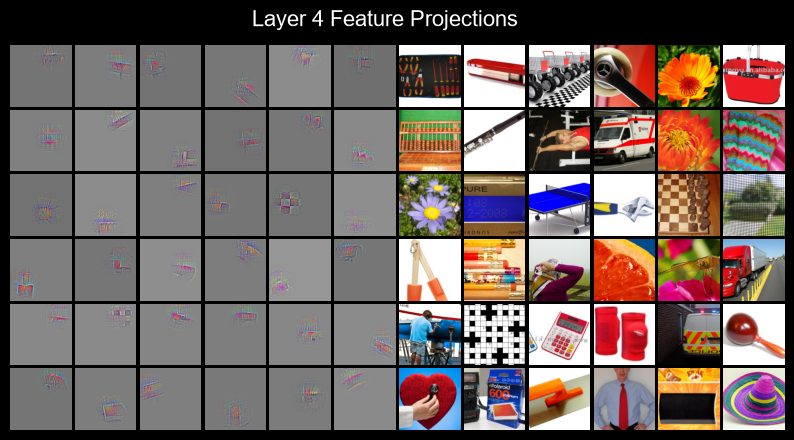

In [33]:
n = 6
layer = 4
val_set = iter(val_data)
feature_plot(n, layer, val_set)

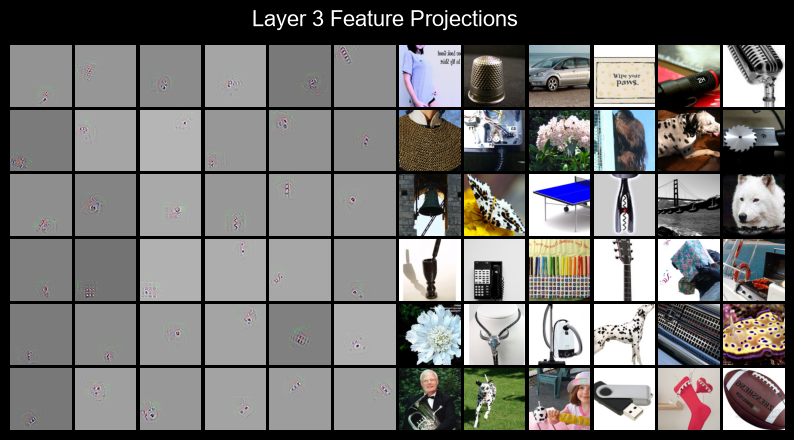

In [34]:
n = 6
layer = 3
val_set = iter(val_data)
feature_plot(n, layer, val_set)

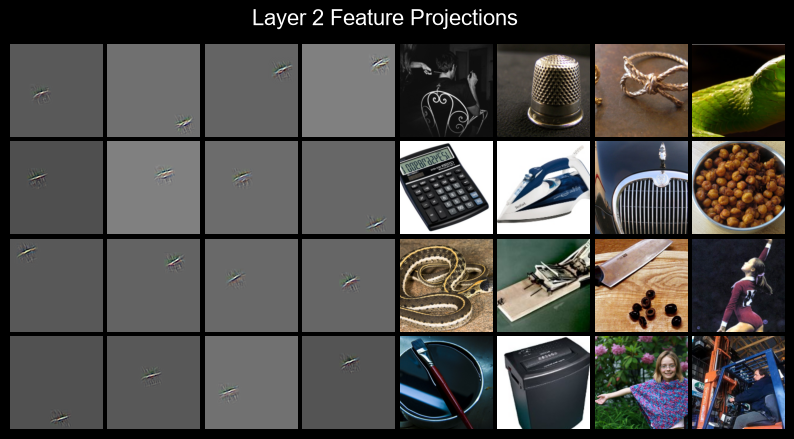

In [35]:
n = 4
layer = 2
val_set = iter(val_data)
feature_plot(n, layer, val_set)

### Filter Invariance (4)

In [27]:
extractor = keras.Model(inputs=model.inputs, outputs=[model.get_layer('conv1').output,
                                                      model.get_layer('dense2').output, model.output])
val_set = iter(val_data)
val_images, val_labels = next(val_set)

NameError: name 'val_set' is not defined

In [ ]:
def analyze_transformations(base_image, true_label_idx):
    base_tensor = torch.tensor(base_image, dtype=torch.float32)
    base_input = base_tensor.unsqueeze(0).numpy()
    f1_base, f7_base, _ = extractor.predict(base_input, verbose=0)
    f1_base, f7_base = f1_base.flatten(), f7_base.flatten()
    results = {
        'translate': {'x': [], 'l1': [], 'l7': [], 'prob': []},
        'scale': {'x': [], 'l1': [], 'l7': [], 'prob': []},
        'rotate': {'x': [], 'l1': [], 'l7': [], 'prob': []}}
    for shift_y in range(-60, 61, 5):
        trans_tensor = TF.affine(base_tensor, angle=0, translate=[0, shift_y], scale=1.0, shear=0)
        f1, f7, preds = extractor.predict(trans_tensor.unsqueeze(0).numpy(), verbose=0)
        results['translate']['x'].append(shift_y)
        results['translate']['l1'].append(np.linalg.norm(f1.flatten() - f1_base))
        results['translate']['l7'].append(np.linalg.norm(f7.flatten() - f7_base))
        results['translate']['prob'].append(preds[0, true_label_idx])

    for scale_factor in np.linspace(1.0, 2.0, 20):
        trans_tensor = TF.affine(base_tensor, angle=0, translate=[0, 0], scale=scale_factor, shear=0)
        f1, f7, preds = extractor.predict(trans_tensor.unsqueeze(0).numpy(), verbose=0)
        results['scale']['x'].append(scale_factor)
        results['scale']['l1'].append(np.linalg.norm(f1.flatten() - f1_base))
        results['scale']['l7'].append(np.linalg.norm(f7.flatten() - f7_base))
        results['scale']['prob'].append(preds[0, true_label_idx])

    for angle in range(0, 361, 15):
        trans_tensor = TF.affine(base_tensor, angle=angle, translate=[0, 0], scale=1.0, shear=0)
        f1, f7, preds = extractor.predict(trans_tensor.unsqueeze(0).numpy(), verbose=0)
        results['rotate']['x'].append(angle)
        results['rotate']['l1'].append(np.linalg.norm(f1.flatten() - f1_base))
        results['rotate']['l7'].append(np.linalg.norm(f7.flatten() - f7_base))
        results['rotate']['prob'].append(preds[0, true_label_idx])
    return results

In [ ]:
sample_images = val_images[:5]
sample_labels = val_labels[:5]
all_results = []
for img, label in zip(sample_images, sample_labels):
    all_results.append(analyze_transformations(img, label))

In [ ]:
def prep_for_display(t_img):
    img = t_img.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-5)
    return img

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(22, 12))
fig.suptitle("Filter Invariance Analysis (Layer 1 vs Layer 7)", fontsize=16)
transforms = ['translate', 'scale', 'rotate']
x_labels = ['Vertical Translation (Pixels)', 'Scale (Ratio)', 'Rotation Degrees']
metrics = ['l1', 'l7', 'prob']
y_labels = ['Canonical Distance (L1)', 'Canonical Distance (L7)', 'P(true class)']
base_tensor = torch.tensor(sample_images[0], dtype=torch.float32)

for row_idx, transform in enumerate(transforms):
    strip_frames = []
    if transform == 'translate':
        steps = [-60, -30, 0, 30, 60]
        for s in steps:
            t = TF.affine(base_tensor, angle=0, translate=[0, s], scale=1.0, shear=0)
            strip_frames.append(prep_for_display(t))

    elif transform == 'scale':
        steps = [1.0, 1.25, 1.5, 1.75, 2.0]
        for s in steps:
            t = TF.affine(base_tensor, angle=0, translate=[0, 0], scale=s, shear=0)
            strip_frames.append(prep_for_display(t))

    elif transform == 'rotate':
        steps = [0, 90, 180, 270, 360]
        for s in steps:
            t = TF.affine(base_tensor, angle=s, translate=[0, 0], scale=1.0, shear=0)
            strip_frames.append(prep_for_display(t))

    image_strip = np.concatenate(strip_frames, axis=1)
    axes[row_idx, 0].imshow(image_strip)
    axes[row_idx, 0].axis('off')

    if row_idx == 0:
        axes[row_idx, 0].set_title("Transformations", fontsize=12)
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx + 1]
        for i in range(5):
            x_data = all_results[i][transform]['x']
            y_data = all_results[i][transform][metric]
            ax.plot(x_data, y_data, label=f'Image {i+1}')
        ax.set_xlabel(x_labels[row_idx])
        ax.set_ylabel(y_labels[col_idx])
        ax.grid(True, alpha=0.3)
        if col_idx == 2:
            ax.set_ylim([0, 1.0])

axes[0, 3].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.subplots_adjust(wspace=0.15, hspace=0.3)
plt.show()

### Occlusion Sensitivity (4.2)

### Correspondence Analysis (4.3)